In [1]:

import pandas as pd
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import pipeline
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import joblib
import re
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer


C:\Users\amirb\PycharmProjects\dataExtractor\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Labeled Dataset with proper label handling

In [2]:
labeled_df = pd.read_csv("test_dataset_with_sentiment.csv")
labeled_df['Final_Comment'] = labeled_df['Final_Comment'].astype(str)

# Create label mapping and convert sentiment to numeric
sentiment_mapping = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
reverse_mapping = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

# Convert sentiment to numeric if needed
if labeled_df['Sentiment'].dtype == object:
    labeled_df['Sentiment'] = labeled_df['Sentiment'].map(sentiment_mapping)
try:
    labeled_df['Sentiment'] = labeled_df['Sentiment'].astype(int)
except ValueError as e:
    print("Error: Sentiment labels must be either 0,1,2 or 'Negative','Neutral','Positive'")
    raise e


# Preprocessing Function

In [3]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text.strip()

# Load Models

In [4]:
# TextBlob + Naive Bayes
# TextBlob + Naive Bayes (pipeline)
complementnb_model_textblob = joblib.load('complementnb_model_textblob.joblib')

# VADER + Naive Bayes (pipeline)
complementnb_model_vader = joblib.load('complementnb_model_vader.joblib')

# BERT
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_tokenizer = BertTokenizer.from_pretrained('./bert_tokenizer')
bert_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)
bert_model.load_state_dict(torch.load('bert_finetuned_sentiment.pt'))
bert_model.to(device)



Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

# Perform Sentiment Analysis Using TextBlob + Naive Bayes

In [5]:
def textblob_analysis(texts):
    return complementnb_model_textblob.predict(texts)

# Perform Sentiment Analysis Using VADER + Naive Bayes (Custom Model)

In [6]:
def vader_analysis_custom(texts):
    return complementnb_model_vader.predict(texts)

# Perform Sentiment Analysis Using BERT

In [7]:
def bert_analysis(texts):
    texts = texts.tolist()
    inputs = bert_tokenizer(texts, padding=True, truncation=True, return_tensors="pt", max_length=128)
    inputs = {key: value.to(device) for key, value in inputs.items()}
    with torch.no_grad():
        outputs = bert_model(**inputs)
    predictions = torch.argmax(outputs.logits, dim=1).cpu().numpy()
    return predictions

# Split Data into Features and Labels

In [8]:
X = labeled_df['Final_Comment']
y = labeled_df['Sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply Sentiment Analysis for Each Model

In [9]:
test_predictions = pd.DataFrame({
    'Final_Comment': X_test,
    'Sentiment': y_test,
    'TextBlob_Prediction': textblob_analysis(X_test),
    'VADER_Prediction': vader_analysis_custom(X_test),
    'BERT_Prediction': bert_analysis(X_test)
})

# Add string labels for visualization
test_predictions['Sentiment_Label'] = test_predictions['Sentiment'].map(reverse_mapping)
test_predictions['TextBlob_Label'] = test_predictions['TextBlob_Prediction'].map(reverse_mapping)
test_predictions['VADER_Label'] = test_predictions['VADER_Prediction'].map(reverse_mapping)
test_predictions['BERT_Label'] = test_predictions['BERT_Prediction'].map(reverse_mapping)


# Cross-Validation for Robust Evaluation

In [10]:
# Cross-Validation for Robust Evaluation (updated for pipeline)

from sklearn.model_selection import cross_val_score, GridSearchCV


def run_cross_validation(pipeline_model, X, y):
    """Run 5-fold cross-validation on a full pipeline model"""
    scores = cross_val_score(pipeline_model, X, y, cv=5, scoring='accuracy')
    print(f"Cross-Validation Accuracy: {np.mean(scores):.2f} ± {np.std(scores):.2f}")


print("TextBlob Model Cross-Validation:")
run_cross_validation(complementnb_model_textblob, X, y)

print("VADER Model Cross-Validation:")
run_cross_validation(complementnb_model_vader, X, y)



TextBlob Model Cross-Validation:
Cross-Validation Accuracy: 0.67 ± 0.03
VADER Model Cross-Validation:
Cross-Validation Accuracy: 0.67 ± 0.03


# Hyperparameter Tuning for Naive Bayes Models


In [11]:
def tune_naive_bayes(pipeline_model, X, y):
    """Use GridSearchCV to tune ComplementNB alpha inside pipeline"""
    parameters = {'complementnb__alpha': [0.1, 0.5, 1.0, 2.0]}
    clf = GridSearchCV(pipeline_model, parameters, cv=3)
    clf.fit(X, y)
    print(f"Best parameters: {clf.best_params_}")
    return clf.best_estimator_

print("Tuning TextBlob Model:")
best_textblob_model = tune_naive_bayes(complementnb_model_textblob, X_train, y_train)

print("Tuning VADER Model:")
best_vader_model = tune_naive_bayes(complementnb_model_vader, X_train, y_train)

Tuning TextBlob Model:
Best parameters: {'complementnb__alpha': 0.5}
Tuning VADER Model:
Best parameters: {'complementnb__alpha': 0.5}


# Evaluate Models with Proper Methodology and Additional Metrics

In [12]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"{model_name} Classification Report:")
    print(classification_report(y_true, y_pred))

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted'
    )
    print(f"Weighted Precision: {precision:.3f}")
    print(f"Weighted Recall: {recall:.3f}")
    print(f"Weighted F1-Score: {f1:.3f}")

    return accuracy_score(y_true, y_pred)


# Evaluate each model
textblob_acc = evaluate_model(test_predictions['Sentiment'],
                              test_predictions['TextBlob_Prediction'],
                              "TextBlob")

vader_acc = evaluate_model(test_predictions['Sentiment'],
                           test_predictions['VADER_Prediction'],
                           "VADER")

bert_acc = evaluate_model(test_predictions['Sentiment'],
                          test_predictions['BERT_Prediction'],
                          "BERT")

TextBlob Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.38      0.37        78
           1       0.46      0.50      0.48       158
           2       0.67      0.58      0.62       154

    accuracy                           0.51       390
   macro avg       0.49      0.49      0.49       390
weighted avg       0.52      0.51      0.51       390

Weighted Precision: 0.521
Weighted Recall: 0.508
Weighted F1-Score: 0.512
VADER Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.85      0.73        78
           1       0.87      0.66      0.75       158
           2       0.85      0.92      0.88       154

    accuracy                           0.80       390
   macro avg       0.79      0.81      0.79       390
weighted avg       0.82      0.80      0.80       390

Weighted Precision: 0.816
Weighted Recall: 0.800
Weighted F1-Score: 0.798
BERT Classification Report:
 

# Confusion Matrices for Each Model (using string labels)

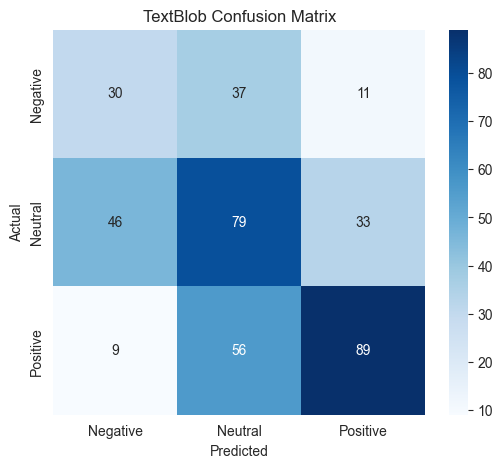

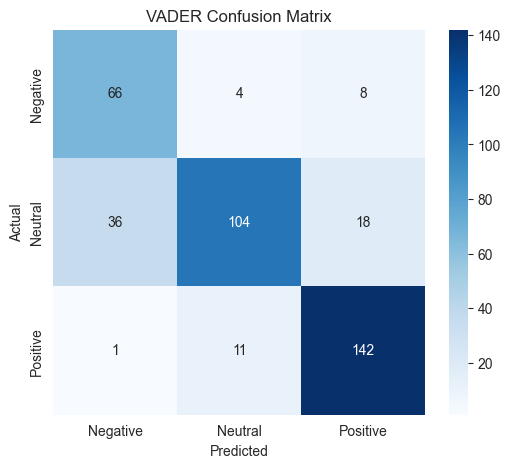

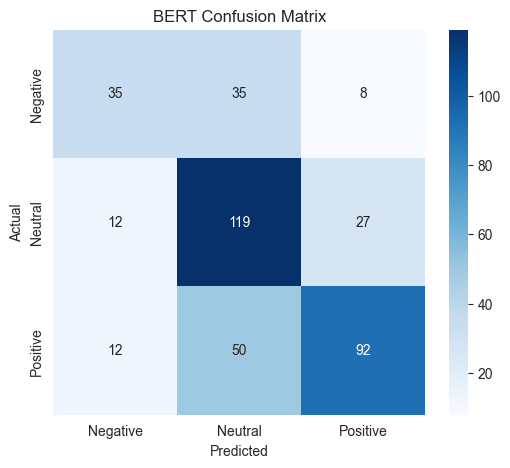

In [13]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Neutral', 'Positive'],
                yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


plot_confusion_matrix(test_predictions['Sentiment'],
                      test_predictions['TextBlob_Prediction'],
                      "TextBlob Confusion Matrix")

plot_confusion_matrix(test_predictions['Sentiment'],
                      test_predictions['VADER_Prediction'],
                      "VADER Confusion Matrix")

plot_confusion_matrix(test_predictions['Sentiment'],
                      test_predictions['BERT_Prediction'],
                      "BERT Confusion Matrix")


# Sentiment Distribution (using string labels

C:\Users\amirb\AppData\Local\Temp\ipykernel_27444\2383034274.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TextBlob_Label', data=df, palette='coolwarm',


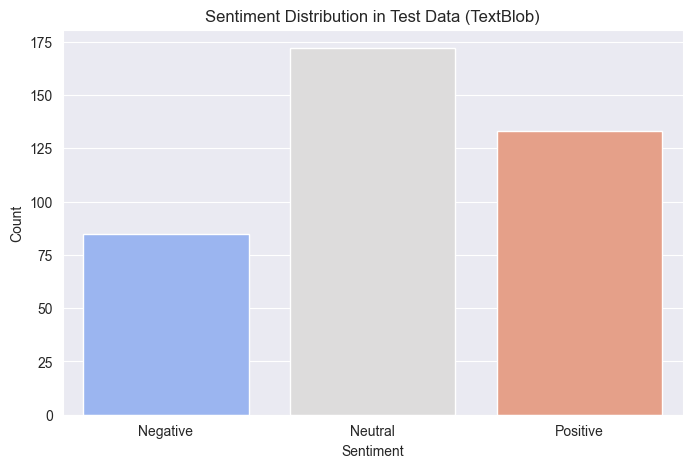

C:\Users\amirb\AppData\Local\Temp\ipykernel_27444\2383034274.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='VADER_Label', data=df, palette='coolwarm',


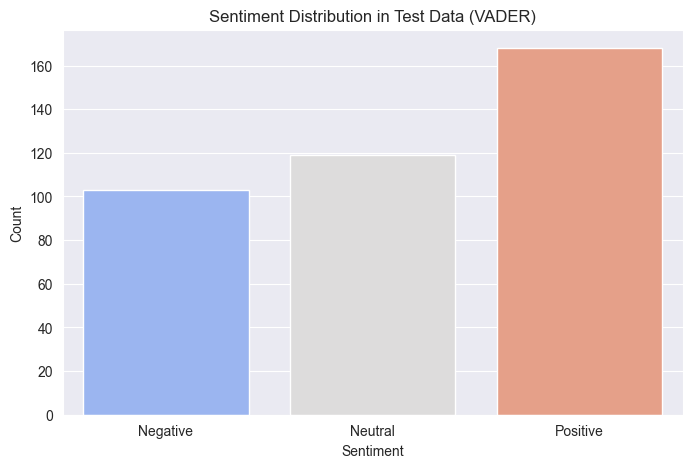

C:\Users\amirb\AppData\Local\Temp\ipykernel_27444\2383034274.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='BERT_Label', data=df, palette='coolwarm',


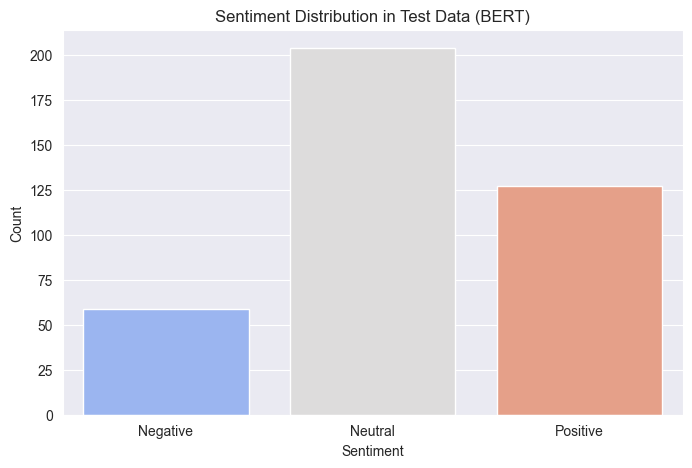

In [14]:
def plot_sentiment_distribution(df, title):
    plt.figure(figsize=(8, 5))
    sns.countplot(x='TextBlob_Label', data=df, palette='coolwarm',
                  order=['Negative', 'Neutral', 'Positive'])
    plt.title(title + " (TextBlob)")
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.countplot(x='VADER_Label', data=df, palette='coolwarm',
                  order=['Negative', 'Neutral', 'Positive'])
    plt.title(title + " (VADER)")
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.countplot(x='BERT_Label', data=df, palette='coolwarm',
                  order=['Negative', 'Neutral', 'Positive'])
    plt.title(title + " (BERT)")
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.show()


plot_sentiment_distribution(test_predictions, "Sentiment Distribution in Test Data")


# Word Clouds for Sentiments


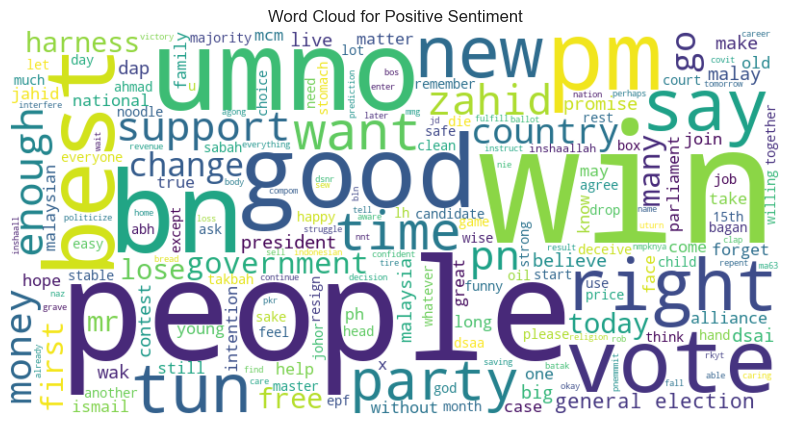

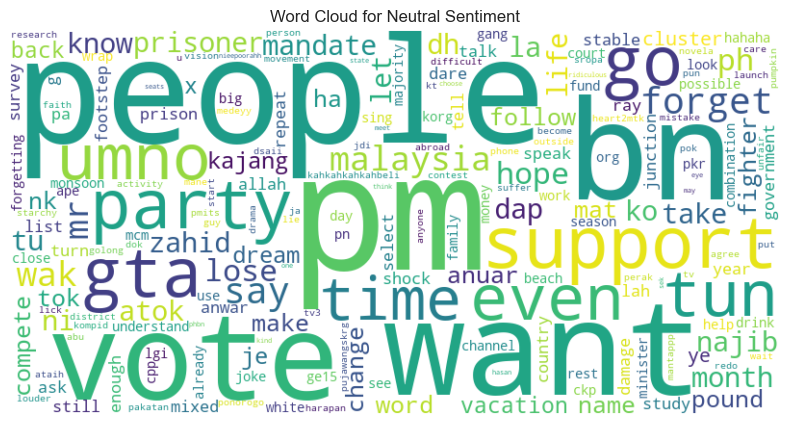

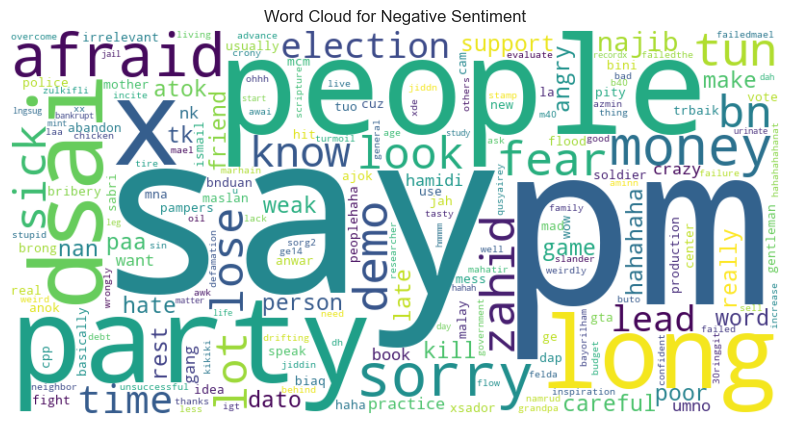

In [15]:
def generate_wordcloud(words, title):
    if not words:
        print(f"Warning: No words available for {title}")
        return
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(words))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title)
    plt.show()


positive_words = ' '.join(
    test_predictions[test_predictions['TextBlob_Prediction'] == 2]['Final_Comment'].apply(preprocess_text)).split()
neutral_words = ' '.join(
    test_predictions[test_predictions['TextBlob_Prediction'] == 1]['Final_Comment'].apply(preprocess_text)).split()
negative_words = ' '.join(
    test_predictions[test_predictions['TextBlob_Prediction'] == 0]['Final_Comment'].apply(preprocess_text)).split()

generate_wordcloud(positive_words, "Word Cloud for Positive Sentiment")
generate_wordcloud(neutral_words, "Word Cloud for Neutral Sentiment")
generate_wordcloud(negative_words, "Word Cloud for Negative Sentiment")

# Compare Models' Performance

C:\Users\amirb\AppData\Local\Temp\ipykernel_27444\866892556.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='coolwarm')


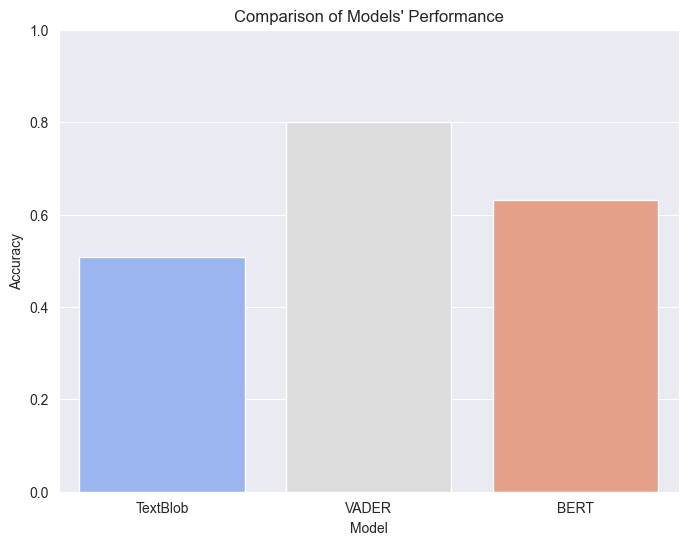

In [16]:
def compare_models_performance(accuracies):
    models = ['TextBlob', 'VADER', 'BERT']
    plt.figure(figsize=(8, 6))
    sns.barplot(x=models, y=accuracies, palette='coolwarm')
    plt.title("Comparison of Models' Performance")
    plt.xlabel('Model')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.0)
    plt.show()

compare_models_performance([textblob_acc, vader_acc, bert_acc])